# Estimate the total number of patterns from partial truncated observations

Joint inference on $S$ (total number of patterns) and $\alpha$ (symmetric Dirichlet concentration), following Section 2.4 of the writeup.

Log joint (up to a constant in $S, \alpha$):
$$
\log P(S, \alpha \mid \vec n, K) \;\propto\; \log \binom{S}{K} + \log\Gamma(S\alpha) - \log\Gamma(N+S\alpha) + \sum_{k=1}^{K}\big[\log\Gamma(\alpha+n_k) - \log\Gamma(\alpha)\big]
$$
with a flat prior on $(S, \alpha)$. We evaluate on a grid and marginalize.

In [1]:
import numpy as np
from scipy.special import gammaln
import matplotlib.pyplot as plt

In [2]:
def joint_log_posterior(counts, S_values, alpha_grid):
    """
    Log of P(S, alpha | n, K) up to a constant, on a grid.
    Returns array shape (len(S_values), len(alpha_grid)).
    """
    counts = np.asarray(counts)
    K = len(counts)
    N = counts.sum()

    S = S_values[:, None].astype(float)        # (nS, 1)
    a = alpha_grid[None, :].astype(float)      # (1, nA)

    # log C(S, K)
    log_binom = gammaln(S + 1) - gammaln(K + 1) - gammaln(S - K + 1)

    # Dirichlet-Multinomial normalization terms
    log_norm = gammaln(S * a) - gammaln(N + S * a)

    # sum_k [lgamma(alpha + n_k) - lgamma(alpha)]
    # shape: (1, nA, K) -> sum over K
    sum_obs = (gammaln(a[..., None] + counts) - gammaln(a[..., None])).sum(axis=-1)
    # sum_obs shape (1, nA)

    return log_binom + log_norm + sum_obs


def posterior_S_alpha(counts, S_max=None, alpha_grid=None):
    """
    Joint inference on (S, alpha) and marginal P(S | n, K).
    Flat prior on both.
    """
    counts = np.asarray(counts)
    K = len(counts)
    if S_max is None:
        S_max = max(10 * K, 50)
    if alpha_grid is None:
        alpha_grid = np.logspace(-2, 2, 200)

    S_values = np.arange(K, S_max + 1)

    log_joint = joint_log_posterior(counts, S_values, alpha_grid)

    # normalize joint with trapezoidal weights in alpha
    log_joint_shift = log_joint - log_joint.max()
    joint = np.exp(log_joint_shift)
    # integrate over alpha (trapezoid) and sum over S to normalize
    Z = np.trapz(joint, alpha_grid, axis=1).sum()
    joint /= Z

    # marginals
    P_S = np.trapz(joint, alpha_grid, axis=1)         # (nS,)
    P_alpha = joint.sum(axis=0)                        # (nA,)
    P_alpha /= np.trapz(P_alpha, alpha_grid)

    return {
        "S_values": S_values,
        "alpha_grid": alpha_grid,
        "joint": joint,
        "P_S": P_S,
        "P_alpha": P_alpha,
    }

In [6]:
def plot_results(counts, res, title=""):
    S_values = res["S_values"]
    alpha_grid = res["alpha_grid"]
    P_S = res["P_S"]
    P_alpha = res["P_alpha"]

    K = len(counts)
    N = int(np.sum(counts))
    MAP_S = int(S_values[np.argmax(P_S)])
    MAP_alpha = float(alpha_grid[np.argmax(P_alpha)])

    # P_S is a discrete pmf over S_values (already normalized via trapezoid in alpha)
    pmf = P_S / P_S.sum()
    E_S = float((S_values * pmf).sum())
    cdf = np.cumsum(pmf)
    lo = int(S_values[np.searchsorted(cdf, 0.025)])
    hi = int(S_values[np.searchsorted(cdf, 0.975)])

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(S_values, P_S, color="steelblue", lw=2)
    axes[0].axvspan(lo, hi, color="orange", alpha=0.15,
                    label=f"95% CI [{lo}, {hi}]")
    axes[0].axvline(MAP_S, color="tomato", ls="--", label=f"MAP S = {MAP_S}")
    axes[0].axvline(E_S, color="darkorange", ls="-.", label=f"E[S] = {E_S:.2f}")
    axes[0].axvline(K, color="gray", ls=":", label=f"K = {K}")
    axes[0].set_xlabel("S")
    axes[0].set_ylabel("P(S | n, K)")
    axes[0].set_title(f"Marginal posterior over S  (N={N}, K={K})")
    axes[0].legend()

    axes[1].plot(alpha_grid, P_alpha, color="seagreen", lw=2)
    axes[1].axvline(MAP_alpha, color="tomato", ls="--",
                    label=f"MAP alpha = {MAP_alpha:.3g}")
    axes[1].set_xscale("log")
    axes[1].set_xlabel("alpha (log scale)")
    axes[1].set_ylabel("P(alpha | n, K)")
    axes[1].set_title("Marginal posterior over alpha")
    axes[1].legend()

    if title:
        fig.suptitle(title)
    plt.tight_layout()
    plt.show()

    print(f"counts = {list(counts)}")
    print(f"  MAP S     = {MAP_S}")
    print(f"  E[S]      = {E_S:.3f}")
    print(f"  95% CI    = [{lo}, {hi}]")
    print(f"  MAP alpha = {MAP_alpha:.4g}")


## 3.1 Large $\alpha$ case (uniform-ish counts)

$\vec n = \{20, 30, 25, 25\}$

/scratch/fast/18103434/ipykernel_2652605/3978025528.py:47: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  Z = np.trapz(joint, alpha_grid, axis=1).sum()
/scratch/fast/18103434/ipykernel_2652605/3978025528.py:51: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  P_S = np.trapz(joint, alpha_grid, axis=1)         # (nS,)
/scratch/fast/18103434/ipykernel_2652605/3978025528.py:53: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  P_alpha /= np.trapz(P_alpha, alpha_grid)


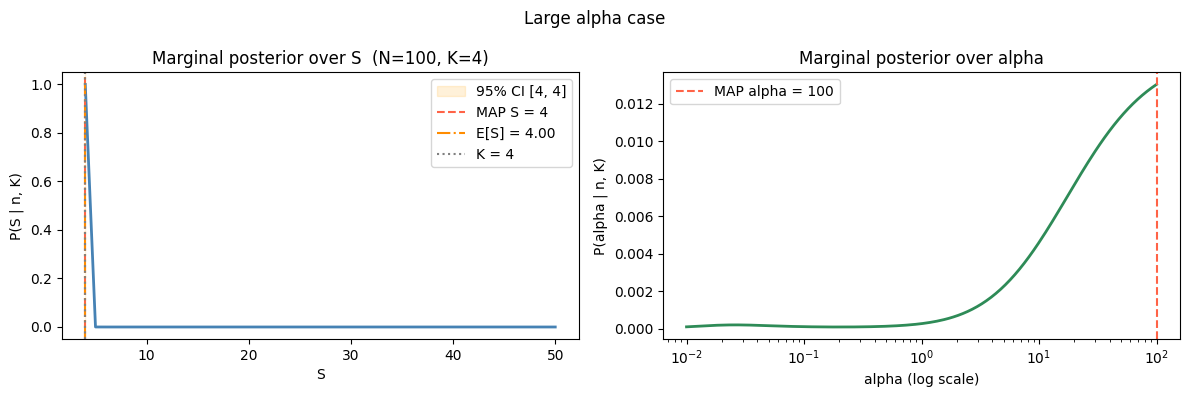

counts = [np.int64(20), np.int64(30), np.int64(25), np.int64(25)]
  MAP S     = 4
  E[S]      = 4.000
  95% CI    = [4, 4]
  MAP alpha = 100


In [7]:
counts_large = np.array([20, 30, 25, 25])
res_large = posterior_S_alpha(counts_large)
plot_results(counts_large, res_large, title="Large alpha case")

## 3.2 Small $\alpha$ case (skewed counts)

$\vec n = \{5, 3, 7, 85\}$

/scratch/fast/18103434/ipykernel_2652605/3978025528.py:47: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  Z = np.trapz(joint, alpha_grid, axis=1).sum()
/scratch/fast/18103434/ipykernel_2652605/3978025528.py:51: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  P_S = np.trapz(joint, alpha_grid, axis=1)         # (nS,)
/scratch/fast/18103434/ipykernel_2652605/3978025528.py:53: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  P_alpha /= np.trapz(P_alpha, alpha_grid)


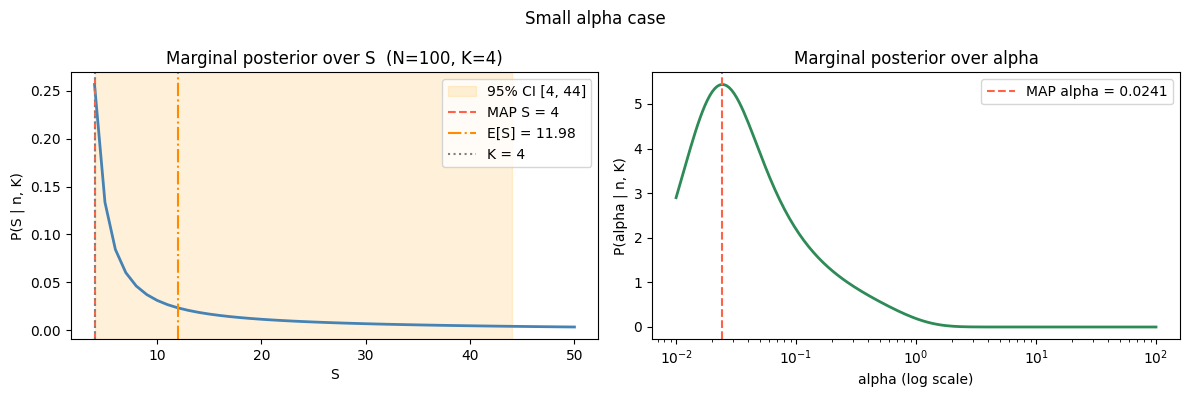

counts = [np.int64(5), np.int64(3), np.int64(7), np.int64(85)]
  MAP S     = 4
  E[S]      = 11.976
  95% CI    = [4, 44]
  MAP alpha = 0.02409


In [8]:
counts_small = np.array([5, 3, 7, 85])
res_small = posterior_S_alpha(counts_small)
plot_results(counts_small, res_small, title="Small alpha case")